# 1. Exploratory Data Analysis (EDA)

**Objective:** Understand the structure, distributions, and quality of the extracted feature datasets before preprocessing.

This notebook inspects:
- Dataset shape and schema consistency across instruments and feature types
- Target label (`roman_numeral`) distribution and class balance
- Feature value ranges and potential anomalies
- Temporal structure (sequence lengths per track)
- Missing values and data quality

> **Note:** This notebook is read-only — it does not modify or save any data.

In [1]:
# ============================================================
# Cell 1 — Imports & Global Configuration
# ============================================================
import os
import pickle
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)

# --- Paths ---
BASE_INPUT = Path('./input')

# --- Constants ---
INSTRUMENTS = sorted([
    d.name for d in BASE_INPUT.iterdir()
    if d.is_dir() and not d.name.startswith('.')
])
FEATURE_TYPES = ['mfcc', 'chromagram', 'mfcc_chroma']
META_COLS = ['track_id', 'part_song', 'chord_absolute', 'roman_numeral', 'start_time', 'end_time']

print(f'Instruments found : {INSTRUMENTS}')
print(f'Feature types     : {FEATURE_TYPES}')

Instruments found : ['bass', 'guitar', 'guitar_piano', 'guitar_piano_bass', 'no_vocals', 'piano', 'raw_audio', 'vocals']
Feature types     : ['mfcc', 'chromagram', 'mfcc_chroma']


In [2]:
# ============================================================
# Cell 2 — Utility: Load Any Feature File
# ============================================================
def load_feature_file(instrument: str, feature_type: str) -> pd.DataFrame:
    """Load extracted features from .pkl (preferred) or .csv fallback."""
    base = BASE_INPUT / instrument / feature_type
    pkl_path = base / f'extracted_features_{feature_type}.pkl'
    csv_path = base / f'extracted_features_{feature_type}.csv'

    if pkl_path.exists():
        with open(pkl_path, 'rb') as f:
            df = pickle.load(f)
        if not isinstance(df, pd.DataFrame):
            raise TypeError(f'Expected DataFrame in pkl, got {type(df)}')
        return df
    elif csv_path.exists():
        return pd.read_csv(csv_path)
    else:
        raise FileNotFoundError(f'No data file found at {base}')

In [3]:
# ============================================================
# Cell 3 — Dataset Overview: Shape & Schema Across All Combinations
# ============================================================
overview_rows = []
for inst in INSTRUMENTS:
    for feat in FEATURE_TYPES:
        try:
            df = load_feature_file(inst, feat)
            n_features = len([c for c in df.columns if c not in META_COLS])
            overview_rows.append({
                'instrument': inst,
                'feature': feat,
                'rows': len(df),
                'columns': len(df.columns),
                'n_features': n_features,
                'n_tracks': df['track_id'].nunique(),
                'n_classes': df['roman_numeral'].nunique(),
                'nan_target': int(df['roman_numeral'].isna().sum()),
            })
        except FileNotFoundError:
            overview_rows.append({'instrument': inst, 'feature': feat, 'rows': 'MISSING'})

overview_df = pd.DataFrame(overview_rows)
display(overview_df)

,instrument,feature,rows,columns,n_features,n_tracks,n_classes,nan_target
0,bass,mfcc,4561,32,26,50,17,13
1,bass,chromagram,4561,30,24,50,17,13
2,bass,mfcc_chroma,4561,56,50,50,17,13
3,guitar,mfcc,4561,32,26,50,17,13
4,guitar,chromagram,4561,30,24,50,17,13
5,guitar,mfcc_chroma,4561,56,50,50,17,13
6,guitar_piano,mfcc,4561,32,26,50,17,13
7,guitar_piano,chromagram,4561,30,24,50,17,13
8,guitar_piano,mfcc_chroma,4561,56,50,50,17,13
9,guitar_piano_bass,mfcc,4561,32,26,50,17,13


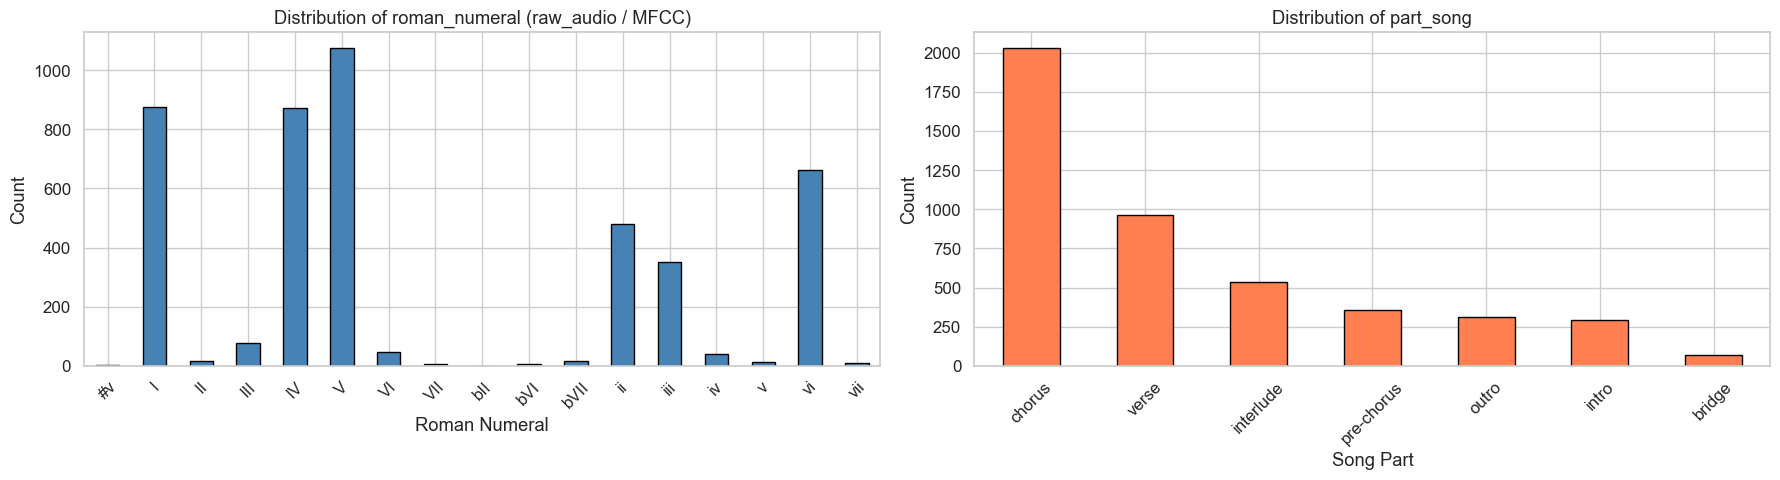


Total rows: 4561
Unique tracks: 50
NaN in roman_numeral: 13


In [4]:
# ============================================================
# Cell 4 — Target Label Distribution (roman_numeral) — raw_audio/mfcc
# ============================================================
df_sample = load_feature_file('raw_audio', 'mfcc')

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# 4a — Roman numeral distribution
label_counts = df_sample['roman_numeral'].value_counts().sort_index()
label_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of roman_numeral (raw_audio / MFCC)')
axes[0].set_xlabel('Roman Numeral')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# 4b — Part song distribution
part_counts = df_sample['part_song'].str.lower().value_counts()
part_counts.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Distribution of part_song')
axes[1].set_xlabel('Song Part')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f'\nTotal rows: {len(df_sample)}')
print(f'Unique tracks: {df_sample["track_id"].nunique()}')
print(f'NaN in roman_numeral: {df_sample["roman_numeral"].isna().sum()}')

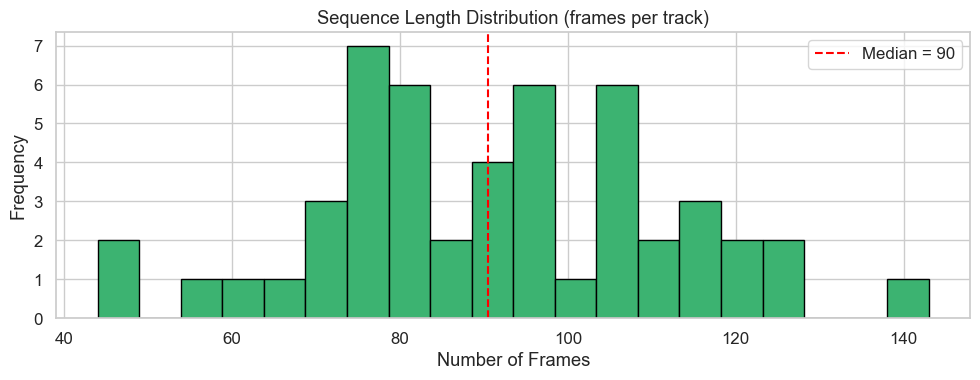

Min: 44, Max: 143, Mean: 91.2, Median: 90.5


In [5]:
# ============================================================
# Cell 5 — Sequence Length Distribution (frames per track)
# ============================================================
seq_lengths = df_sample.groupby('track_id').size()

fig, ax = plt.subplots(figsize=(10, 4))
seq_lengths.plot(kind='hist', bins=20, ax=ax, color='mediumseagreen', edgecolor='black')
ax.axvline(seq_lengths.median(), color='red', linestyle='--', label=f'Median = {seq_lengths.median():.0f}')
ax.set_title('Sequence Length Distribution (frames per track)')
ax.set_xlabel('Number of Frames')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Min: {seq_lengths.min()}, Max: {seq_lengths.max()}, Mean: {seq_lengths.mean():.1f}, Median: {seq_lengths.median():.1f}')

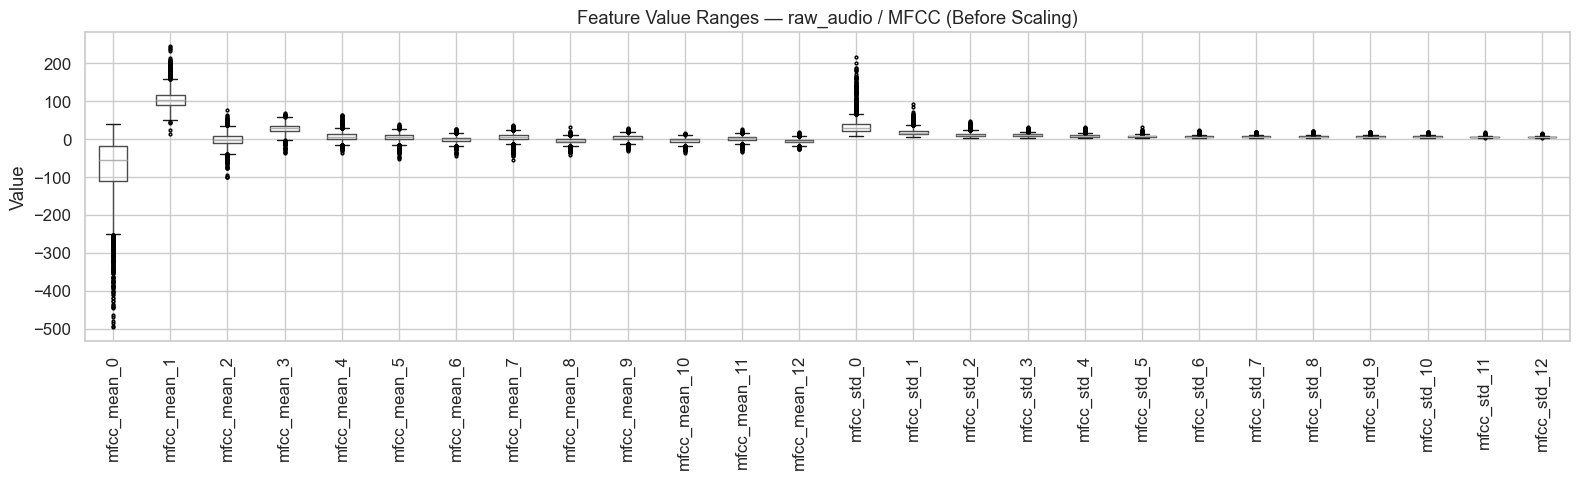

In [6]:
# ============================================================
# Cell 6 — Feature Value Ranges (Box Plot)
# ============================================================
feat_cols = [c for c in df_sample.columns if c not in META_COLS]

fig, ax = plt.subplots(figsize=(16, 5))
df_sample[feat_cols].boxplot(ax=ax, rot=90, flierprops=dict(markersize=2))
ax.set_title('Feature Value Ranges — raw_audio / MFCC (Before Scaling)')
ax.set_ylabel('Value')
plt.tight_layout()
plt.show()

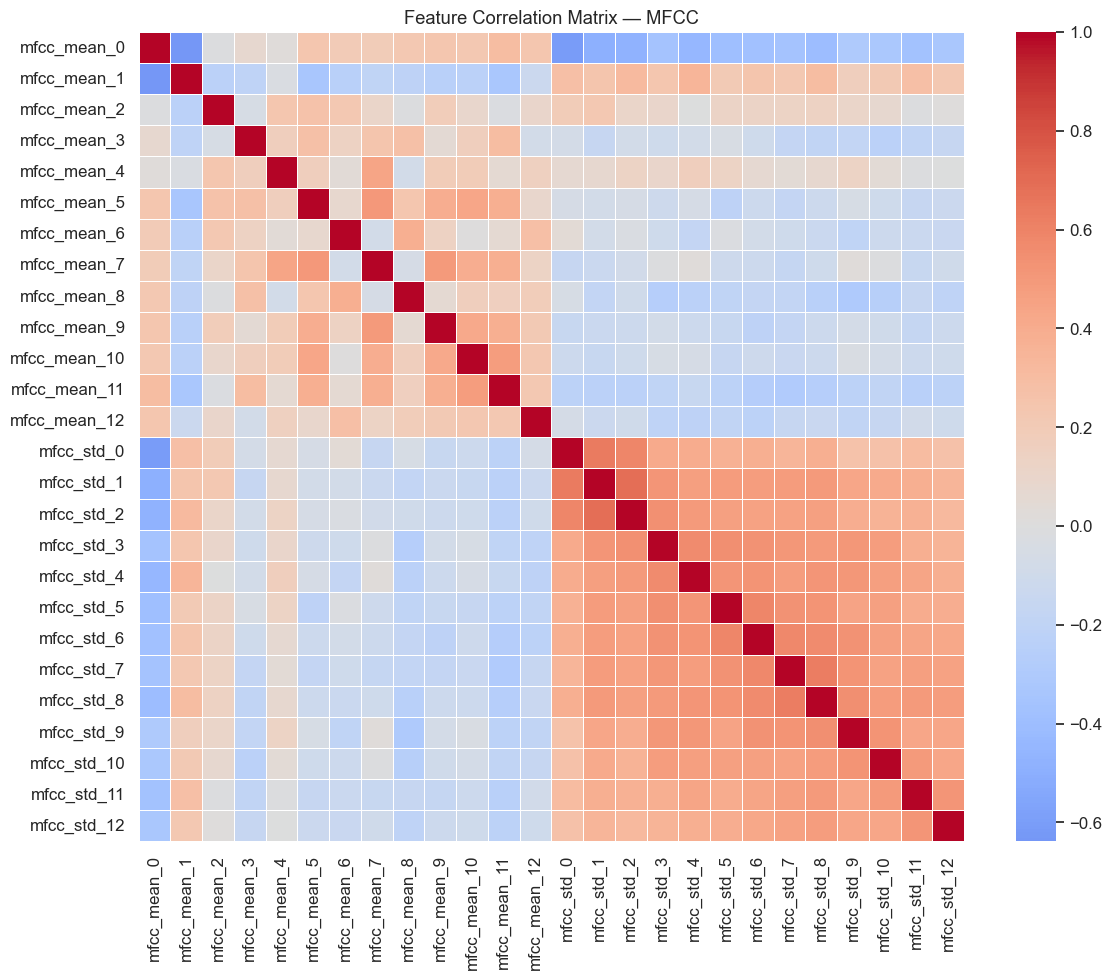

In [7]:
# ============================================================
# Cell 7 — Correlation Heatmap (Feature-to-Feature)
# ============================================================
corr = df_sample[feat_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax,
            xticklabels=True, yticklabels=True, linewidths=0.5)
ax.set_title('Feature Correlation Matrix — MFCC')
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# Cell 8 — Compare Feature Dimensions Across Feature Types
# ============================================================
for feat in FEATURE_TYPES:
    df_tmp = load_feature_file('raw_audio', feat)
    feat_c = [c for c in df_tmp.columns if c not in META_COLS]
    print(f'{feat:15s} → {len(feat_c)} feature dims  |  columns: {feat_c[:5]} ... {feat_c[-3:]}')

mfcc            → 26 feature dims  |  columns: ['mfcc_mean_0', 'mfcc_mean_1', 'mfcc_mean_2', 'mfcc_mean_3', 'mfcc_mean_4'] ... ['mfcc_std_10', 'mfcc_std_11', 'mfcc_std_12']
chromagram      → 24 feature dims  |  columns: ['chroma_mean_0', 'chroma_mean_1', 'chroma_mean_2', 'chroma_mean_3', 'chroma_mean_4'] ... ['chroma_std_9', 'chroma_std_10', 'chroma_std_11']
mfcc_chroma     → 50 feature dims  |  columns: ['mfcc_mean_0', 'mfcc_mean_1', 'mfcc_mean_2', 'mfcc_mean_3', 'mfcc_mean_4'] ... ['chroma_std_9', 'chroma_std_10', 'chroma_std_11']


---
## Summary

Key observations from EDA:
- **Consistent schema** across all instrument × feature combinations (6 metadata + N feature columns)
- **Target variable** (`roman_numeral`) has ~17 unique classes with some NaN rows to be dropped during preprocessing
- **Class imbalance** is present — some roman numerals are significantly more frequent
- **Feature scales vary widely** (especially MFCC), confirming the need for StandardScaler
- **50 unique tracks** in each dataset, providing natural sequence boundaries

→ Proceed to `2_preprocessing.ipynb`